In [26]:
from pytrends import dailydata
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
res = dailydata.get_daily_data("bitcoin", start_year=2016, start_mon=1, stop_year=2026, stop_mon=2, geo = '')

bitcoin:2016-01-01 2016-01-31
bitcoin:2016-02-01 2016-02-29
bitcoin:2016-03-01 2016-03-31
bitcoin:2016-04-01 2016-04-30
bitcoin:2016-05-01 2016-05-31
bitcoin:2016-06-01 2016-06-30
bitcoin:2016-07-01 2016-07-31
bitcoin:2016-08-01 2016-08-31
bitcoin:2016-09-01 2016-09-30
bitcoin:2016-10-01 2016-10-31
bitcoin:2016-11-01 2016-11-30
bitcoin:2016-12-01 2016-12-31
bitcoin:2017-01-01 2017-01-31
bitcoin:2017-02-01 2017-02-28
bitcoin:2017-03-01 2017-03-31
bitcoin:2017-04-01 2017-04-30
bitcoin:2017-05-01 2017-05-31
bitcoin:2017-06-01 2017-06-30
bitcoin:2017-07-01 2017-07-31
bitcoin:2017-08-01 2017-08-31
bitcoin:2017-09-01 2017-09-30
bitcoin:2017-10-01 2017-10-31
bitcoin:2017-11-01 2017-11-30
bitcoin:2017-12-01 2017-12-31
bitcoin:2018-01-01 2018-01-31
bitcoin:2018-02-01 2018-02-28
bitcoin:2018-03-01 2018-03-31
bitcoin:2018-04-01 2018-04-30
bitcoin:2018-05-01 2018-05-31
bitcoin:2018-06-01 2018-06-30
bitcoin:2018-07-01 2018-07-31
bitcoin:2018-08-01 2018-08-31
bitcoin:2018-09-01 2018-09-30
bitcoin:20

C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytrends\dailydata.py:123: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  complete[f'{word}_monthly'].ffill(inplace=True)  # fill NaN values


In [19]:
res

,bitcoin_unscaled,bitcoin_monthly,isPartial,scale,bitcoin
date,,,,,
2016-01-01,66,3.0,False,0.03,1.98
2016-01-02,65,3.0,NaN,0.03,1.95
2016-01-03,69,3.0,NaN,0.03,2.07
2016-01-04,71,3.0,NaN,0.03,2.13
2016-01-05,72,3.0,NaN,0.03,2.16
...,...,...,...,...,...
2026-02-24,30,41.0,NaN,0.41,12.30
2026-02-25,27,41.0,NaN,0.41,11.07
2026-02-26,25,41.0,NaN,0.41,10.25


In [20]:
gt = res.rename(columns={"bitcoin": "google_trend"})
gt = gt.sort_index()

In [22]:
gt["gtrend_change"] = gt["google_trend"].diff()
gt["gtrend_pct_change"] = gt["google_trend"].pct_change()

In [23]:
gt

,bitcoin_unscaled,bitcoin_monthly,isPartial,scale,google_trend,gtrend_change,gtrend_pct_change
date,,,,,,,
2016-01-01,66,3.0,False,0.03,1.98,NaN,NaN
2016-01-02,65,3.0,NaN,0.03,1.95,-0.03,-0.015152
2016-01-03,69,3.0,NaN,0.03,2.07,0.12,0.061538
2016-01-04,71,3.0,NaN,0.03,2.13,0.06,0.028986
2016-01-05,72,3.0,NaN,0.03,2.16,0.03,0.014085
...,...,...,...,...,...,...,...
2026-02-24,30,41.0,NaN,0.41,12.30,0.41,0.034483
2026-02-25,27,41.0,NaN,0.41,11.07,-1.23,-0.100000
2026-02-26,25,41.0,NaN,0.41,10.25,-0.82,-0.074074


In [24]:
gt = gt.loc["2016-02-01":"2026-02-01"]

In [25]:
gt

,bitcoin_unscaled,bitcoin_monthly,isPartial,scale,google_trend,gtrend_change,gtrend_pct_change
date,,,,,,,
2016-02-01,86,3.0,False,0.03,2.58,0.60,0.303030
2016-02-02,82,3.0,NaN,0.03,2.46,-0.12,-0.046512
2016-02-03,81,3.0,NaN,0.03,2.43,-0.03,-0.012195
2016-02-04,85,3.0,NaN,0.03,2.55,0.12,0.049383
2016-02-05,81,3.0,NaN,0.03,2.43,-0.12,-0.047059
...,...,...,...,...,...,...,...
2026-01-28,57,24.0,NaN,0.24,13.68,-0.96,-0.065574
2026-01-29,76,24.0,NaN,0.24,18.24,4.56,0.333333
2026-01-30,89,24.0,NaN,0.24,21.36,3.12,0.171053


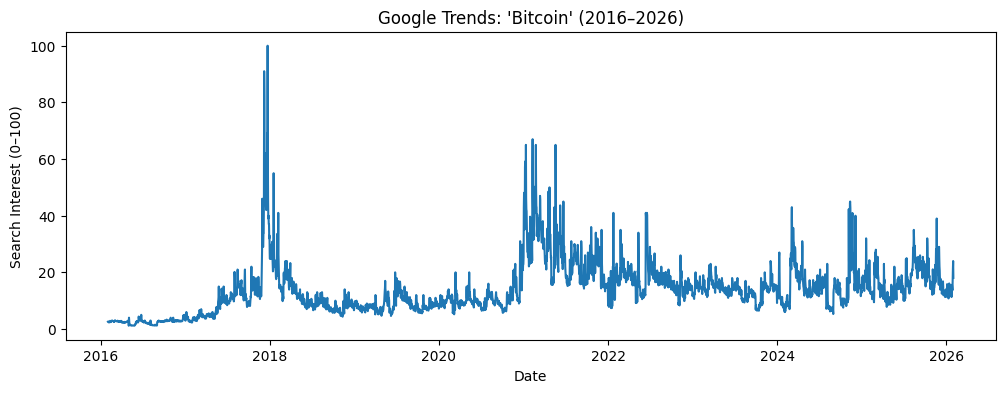

In [27]:
plt.figure(figsize=(12,4))
plt.plot(gt.index, gt["google_trend"])
plt.title("Google Trends: 'Bitcoin' (2016–2026)")
plt.xlabel("Date")
plt.ylabel("Search Interest (0–100)")
plt.show()

In [29]:
gt.to_csv("google_trends_bitcoin_daily.csv")